In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update("jax_enable_x64", True)
import jax
import matplotlib
import matplotlib.pyplot as pl
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
import jax_cosmo.background as bkgrd
import time
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
pl.rc('text', usetex=True)



/tmp/ipykernel_827406/2127409384.py:5: DeprecationWarning: jax.lib.xla_bridge module will be removed in JAX v0.9.0; all its APIs were deprecated and removed by JAX v0.8.0.
  from jax.lib import xla_bridge


1 1


In [ ]:
import yaml
import pathlib
from deepmerge import always_merger
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 


# Load the parameters into a dictionary:
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# Load the n(z) for the lens catalogs. 
# This is for spectroscopic survey. So there is comoving n(z) provided
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving_orig = df_nz_comoving[:,1]
indsel = np.where(zarray_comoving < 0.4)[0]
nz_comoving = np.zeros_like(zarray_comoving)
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
indsel = np.where(zarray_comoving > 0.4)[0]
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving



from scipy.interpolate import interp1d
# ks = np.geomspace(5e-2,50,15) # wavenumbers
ks = np.geomspace(3e-1,10,10) # wavenumbers
zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

# This is the actual n(z) from the comoving n(z):
nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
analysis_dict['nz_lens_info_dict'] = nz_info_dict



/tmp/ipykernel_827406/598427721.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_827406/598427721.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)


## Run the code

In [3]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov
import matplotlib.pyplot as pl

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)



## For plotting:

In [4]:
M_array = base_test.M_array
z_array = base_test.z_array
r_array = base_test.r_array
k_array = base_test.kPk_array
ell_array = base_test.ell_array


## Ncen, Nsats:

Text(0, 0.5, 'Ngals')

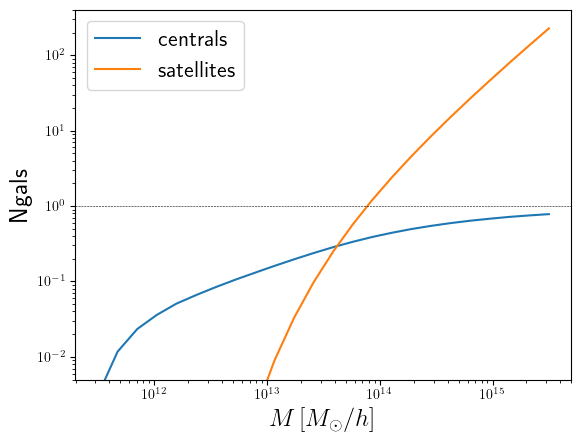

In [5]:
z_plot = 0.5
indz = np.argmin(np.abs(z_array - z_plot))
pl.figure()
pl.plot(M_array, profiles_test.Ncen_mat[indz,:], label='centrals')
pl.plot(M_array, profiles_test.Nsat_mat[indz,:], label='satellites')
pl.xscale('log')
pl.yscale('log')
pl.ylim(5e-3, 400)
pl.legend(fontsize=16)
pl.axhline(1.0, color='k', ls='--', lw=0.4)
pl.xlabel(r'$M\, [M_\odot/h]$', fontsize=18)
pl.ylabel(r'Ngals', fontsize=18)


## mass fractions

Text(0, 0.5, 'Mass fraction')

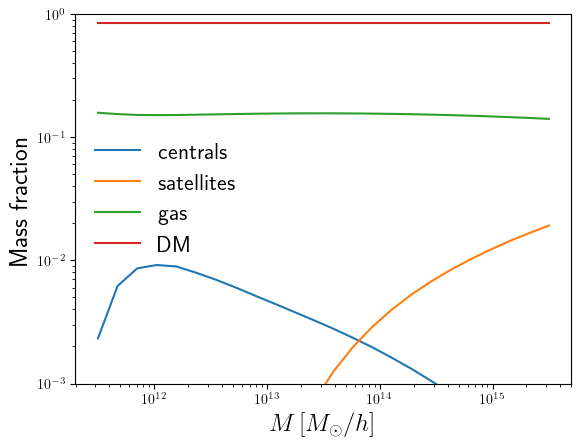

In [6]:
z_plot = 0.5
indz = np.argmin(np.abs(z_array - z_plot))
pl.figure()
pl.plot(M_array, profiles_test.fstar_cen_mat[indz,:], label='centrals')
pl.plot(M_array, profiles_test.fstar_sat_mat[indz,:], label='satellites')
pl.plot(M_array, profiles_test.fgas_mat[indz,:], label='gas')
pl.plot(M_array, profiles_test.fclm_mat[indz,:] - profiles_test.fstar_sat_mat[indz,:], label='DM')
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-3, 1)
pl.legend(fontsize=16, frameon=False)
pl.xlabel(r'$M\, [M_\odot/h]$', fontsize=18)
pl.ylabel(r'Mass fraction', fontsize=18)


## Profiles

Text(0, 0.5, '$\\rho\\,$ (M$_\\odot/h^2$)')

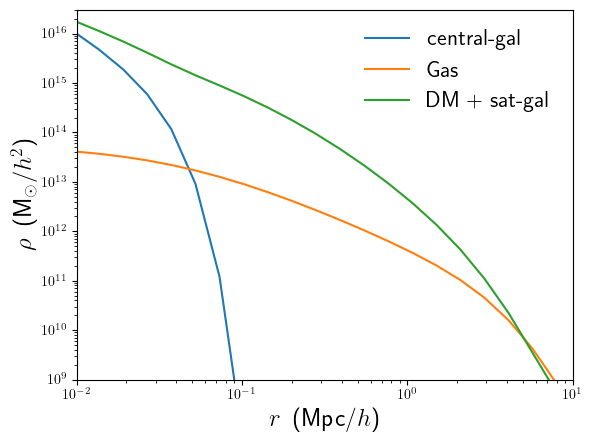

In [7]:
z_plot = 0.5
indz = np.argmin(np.abs(z_array - z_plot))
lg10M_plot = 14.0
indM = np.argmin(np.abs(np.log10(M_array) - lg10M_plot))
pl.figure()
pl.plot(r_array, profiles_test.rho_cga_mat[:, indz,indM], label='central-gal')
pl.plot(r_array, profiles_test.rho_gas_mat[:, indz,indM], label='Gas')
pl.plot(r_array, profiles_test.rho_clm_mat[:, indz,indM], label='DM + sat-gal')
# pl.plot(M_array, profiles_test.fclm_mat[indz,:] - profiles_test.fstar_sat_mat[indz,:], label='DM')
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e9, 3e16)
pl.xlim(1e-2, 1e1)
pl.legend(fontsize=16, frameon=False)
pl.xlabel(r'$r\,$ (Mpc/$h$)', fontsize=18)
pl.ylabel(r'$\rho\,$ (M$_\odot/h^2$)', fontsize=18)


## Power spectra

Text(0, 0.5, '$P_{gg}(k)\\, [(\\mathrm{Mpc}/h)^3]$')

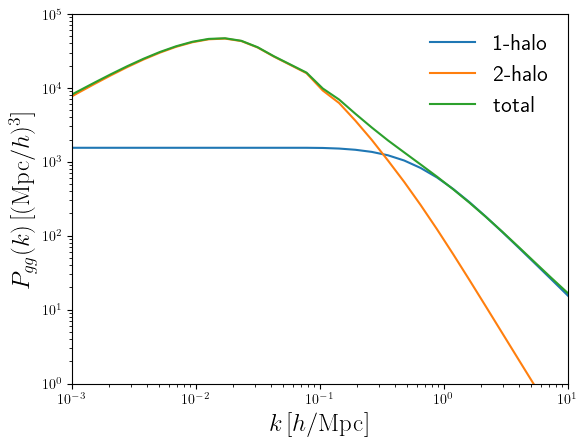

In [8]:
z_plot = 0.5
indz = np.argmin(np.abs(z_array - z_plot))
pl.figure()
pl.plot(k_array, Pkz_test.Pgg_1h_kz_mat[:, indz], label='1-halo')
pl.plot(k_array, Pkz_test.Pgg_2h_kz_mat[:, indz], label='2-halo')
pl.plot(k_array, Pkz_test.Pgg_tot_mat[:, indz], label='total')
pl.xscale('log')
pl.yscale('log')
pl.xlim(1e-3, 1e1)
pl.ylim(1e0, 1e5)
pl.legend(fontsize=16, frameon=False)
pl.xlabel(r'$k\, [h/\mathrm{Mpc}]$', fontsize=18)
pl.ylabel(r'$P_{gg}(k)\, [(\mathrm{Mpc}/h)^3]$', fontsize=18)


## Cls


Text(0, 0.5, '$C_{gg}(\\ell)$')

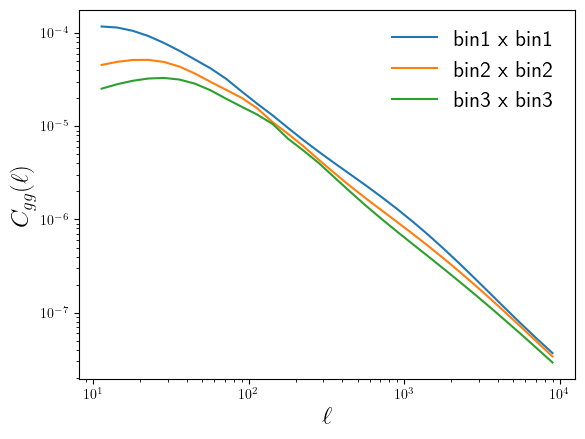

In [ ]:
z_plot = 0.5
indz = np.argmin(np.abs(z_array - z_plot))
pl.figure()
pl.plot(ell_array, Cls_test.Cl_gal_gal_tot_mat[:,0,0], label='bin1 x bin1')
pl.plot(ell_array, Cls_test.Cl_gal_gal_tot_mat[:,1,1], label='bin2 x bin2')
pl.plot(ell_array, Cls_test.Cl_gal_gal_tot_mat[:,2,2], label='bin3 x bin3')
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=16, frameon=False)
pl.xlabel(r'$\ell$', fontsize=18)
pl.ylabel(r'$C_{gg}(\ell)$', fontsize=18)


